"""
plot_ETL_HTL_contour_fixed.py
================================
ETL/HTL thickness contour — Fig. 6 replica
Reads: ETL_HTL_sweep_results.csv

Fixes from previous version:
  1. White background (no terminal dark theme)
  2. Contour labels on all panels
  3. Best PCE point marked with star on all panels
  4. Proper titles and paper reference
  5. Physical explanation annotations

HOW TO RUN:
    Place in same folder as ETL_HTL_sweep_results.csv
    python plot_ETL_HTL_contour_fixed.py
"""

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.interpolate import griddata

# ─────────────────────────────────────────────────────────────────────────────
# LOAD DATA
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv("ETL_HTL_sweep_results.csv")

etl = df["ETL_Thickness_um"].values
htl = df["HTL_Thickness_um"].values
jsc = df["Jsc_mA_cm2"].values
voc = df["Voc_V"].values
ff  = df["FF_percent"].values
pce = df["PCE_percent"].values

print(f"Grid : {len(np.unique(etl))} ETL × {len(np.unique(htl))} HTL = {len(df)} points")
print(f"PCE  : {pce.min():.3f}% – {pce.max():.3f}%")

best_idx = int(np.argmax(pce))
best_etl = etl[best_idx]
best_htl = htl[best_idx]
print(f"Best : PCE={pce[best_idx]:.4f}%  ETL={best_etl:.3f}µm  HTL={best_htl:.3f}µm")

Grid : 50 ETL × 50 HTL = 2500 points
PCE  : 26.380% – 27.020%
Best : PCE=27.0200%  ETL=0.100µm  HTL=0.100µm


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# INTERPOLATION GRID
# ─────────────────────────────────────────────────────────────────────────────

xi = np.linspace(etl.min(), etl.max(), 300)
yi = np.linspace(htl.min(), htl.max(), 300)
XI, YI = np.meshgrid(xi, yi)
pts = np.column_stack([etl, htl])

ZI_jsc = griddata(pts, jsc, (XI, YI), method="cubic")
ZI_voc = griddata(pts, voc, (XI, YI), method="cubic")
ZI_ff  = griddata(pts, ff,  (XI, YI), method="cubic")
ZI_pce = griddata(pts, pce, (XI, YI), method="cubic")

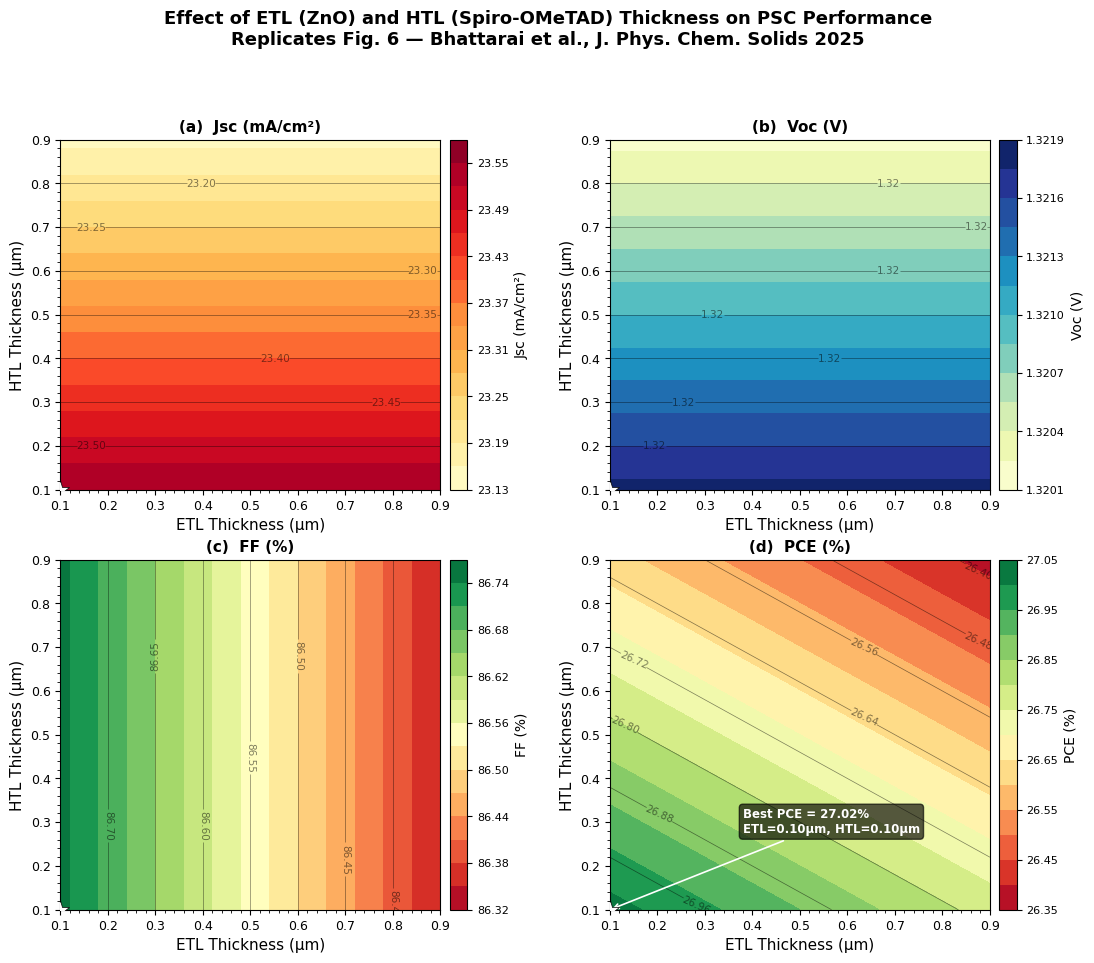

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# 4-PANEL CONTOUR PLOT
# ─────────────────────────────────────────────────────────────────────────────

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "savefig.facecolor":"white",
})

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle(
    "Effect of ETL (ZnO) and HTL (Spiro-OMeTAD) Thickness on PSC Performance\n"
    "Replicates Fig. 6 — Bhattarai et al., J. Phys. Chem. Solids 2025",
    fontsize=13, fontweight="bold", y=1.01
)

panels = [
    (ZI_jsc, "Jsc (mA/cm²)", "YlOrRd", "(a)", jsc),
    (ZI_voc, "Voc (V)",       "YlGnBu", "(b)", voc),
    (ZI_ff,  "FF (%)",        "RdYlGn", "(c)", ff),
    (ZI_pce, "PCE (%)",       "RdYlGn", "(d)", pce),
]

for ax, (Z, label, cmap, tag, raw) in zip(axes.flat, panels):

    # filled contour
    cf = ax.contourf(XI, YI, Z, levels=15, cmap=cmap)

    # contour lines with labels
    n_lines = 8
    cs = ax.contour(XI, YI, Z, levels=n_lines,
                    colors="k", linewidths=0.5, alpha=0.5)
    ax.clabel(cs, inline=True, fontsize=7.5,
              fmt="%.2f", inline_spacing=2)

    # colorbar
    cbar = fig.colorbar(cf, ax=ax, pad=0.02)
    cbar.set_label(label, fontsize=10)
    cbar.ax.tick_params(labelsize=8)

    # best PCE star on all panels
    ax.plot(best_etl, best_htl, "w*", markersize=14,
            zorder=6, markeredgecolor="black", markeredgewidth=0.5)

    # label best point only on PCE panel
    if "PCE" in label:
        ax.annotate(
            f"Best PCE = {pce[best_idx]:.2f}%\n"
            f"ETL={best_etl:.2f}µm, HTL={best_htl:.2f}µm",
            xy=(best_etl, best_htl),
            xytext=(0.35, 0.22),
            textcoords="axes fraction",
            fontsize=8.5, color="white", fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="black", alpha=0.65),
            arrowprops=dict(arrowstyle="->", color="white", lw=1.2)
        )

    ax.set_xlabel("ETL Thickness (µm)", fontsize=11)
    ax.set_ylabel("HTL Thickness (µm)", fontsize=11)
    ax.set_title(f"{tag}  {label}", fontsize=11, fontweight="bold")
    ax.tick_params(labelsize=9)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.set_xlim(etl.min(), etl.max())
    ax.set_ylim(htl.min(), htl.max())

In [4]:
plt.tight_layout()
plt.savefig("ETL_HTL_contour_FIXED.png", dpi=300, bbox_inches="tight",
            facecolor="white")
print("\nSaved --> ETL_HTL_contour_FIXED.png")
plt.show()


Saved --> ETL_HTL_contour_FIXED.png


<Figure size 640x480 with 0 Axes>